# 03. Annotate Day 0 retinal cell types

This notebook annotates Leiden clusters from `02_clustered.h5ad` using retinal marker genes and saves `data/processed/03_annotated.h5ad`.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("whitegrid")

/var/folders/bw/h94700p51374zgrbzwg8hrbh0000gn/T/ipykernel_93356/363729404.py:9: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)


In [10]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "samples.tsv").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find day0_insm1_scrna project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ANNOTATION_DIR = PROJECT_ROOT / "results" / "annotation"

INPUT_H5AD = INTERIM_DIR / "02_clustered.h5ad"
OUTPUT_H5AD = PROCESSED_DIR / "03_annotated.h5ad"
CLUSTER_KEY = "leiden_res_0.50"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATION_DIR.mkdir(parents=True, exist_ok=True)
print(f"Input object: {INPUT_H5AD}")

Input object: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna/data/interim/02_clustered.h5ad


In [11]:
adata = sc.read_h5ad(INPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 35212 × 33696
    obs: 'sample_id', 'day', 'genotype', 'condition', 'feature_matrix_h5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.30', 'leiden_res_0.30_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: '

In [12]:
marker_genes = {
    "Rod": ["Rho", "Gnat1", "Pde6a", "Pde6b", "Cnga1", "Nr2e3", "Nrl", "Prph2", "Rom1"],
    "Cone": ["Pde6h", "Arr3", "Opn1mw", "Gnat2", "Pde6c", "Opn1sw"],
    "BC": ["Vsx1", "Vsx2", "Car10", "Otx2os1", "Gng13", "Nrxn3", "Gabrb3", "Trnp1", "Kcnma1", "Frmd3", "Gm4792", "Nyap2"],
    "AC": ["Tfap2a", "Tfap2b", "Pax6", "Frmd5", "Nrg3", "Elavl3", "Gad1", "Gad2"],
    "MG": ["Rlbp1", "Glul", "Dkk3", "Adamtsl1", "Gpr37", "Abca8a", "Rgs6", "Spc25", "Clu", "Apoe", "Aqp4"],
    "HC": ["Calb1", "Onecut1", "Slc4a3", "Onecut2", "Gm45459", "C1ql1"],
    "RGC": ["Nefl", "Stmn2", "Nrn1", "Pou4f1", "Pou4f2", "Sncg", "Stmn2", "Rbpms"],
    "RPE": ["Ttr", "Rdh5", "Rgr", "Slc16a8"],
    "Astrocyte": ["S100b", "Gfap", "Mlc1", "Prdx6", "Pdgfra"],
    "Microglia": ["Ctss", "C1qa", "Hexb", "Trem2"],
    "Endothelial": ["Cldn5", "Flt1", "Ly6c1", "Ptprb"],
}

available_marker_genes = {
    cell_type: [gene for gene in genes if gene in adata.var_names]
    for cell_type, genes in marker_genes.items()
}
available_marker_genes

{'Rod': ['Rho',
  'Gnat1',
  'Pde6a',
  'Pde6b',
  'Cnga1',
  'Nr2e3',
  'Nrl',
  'Prph2',
  'Rom1'],
 'Cone': ['Pde6h', 'Arr3', 'Opn1mw', 'Gnat2', 'Pde6c', 'Opn1sw'],
 'BC': ['Vsx1',
  'Vsx2',
  'Car10',
  'Otx2os1',
  'Gng13',
  'Nrxn3',
  'Gabrb3',
  'Trnp1',
  'Kcnma1',
  'Frmd3',
  'Gm4792',
  'Nyap2'],
 'AC': ['Tfap2a', 'Tfap2b', 'Pax6', 'Frmd5', 'Nrg3', 'Elavl3', 'Gad1', 'Gad2'],
 'MG': ['Rlbp1',
  'Glul',
  'Dkk3',
  'Adamtsl1',
  'Gpr37',
  'Abca8a',
  'Rgs6',
  'Spc25',
  'Clu',
  'Apoe',
  'Aqp4'],
 'HC': ['Calb1', 'Onecut1', 'Slc4a3', 'Onecut2', 'Gm45459', 'C1ql1'],
 'RGC': ['Nefl',
  'Stmn2',
  'Nrn1',
  'Pou4f1',
  'Pou4f2',
  'Sncg',
  'Stmn2',
  'Rbpms'],
 'RPE': ['Ttr', 'Rdh5', 'Rgr', 'Slc16a8'],
 'Astrocyte': ['S100b', 'Gfap', 'Mlc1', 'Prdx6', 'Pdgfra'],
 'Microglia': ['Ctss', 'C1qa', 'Hexb', 'Trem2'],
 'Endothelial': ['Cldn5', 'Flt1', 'Ly6c1', 'Ptprb']}

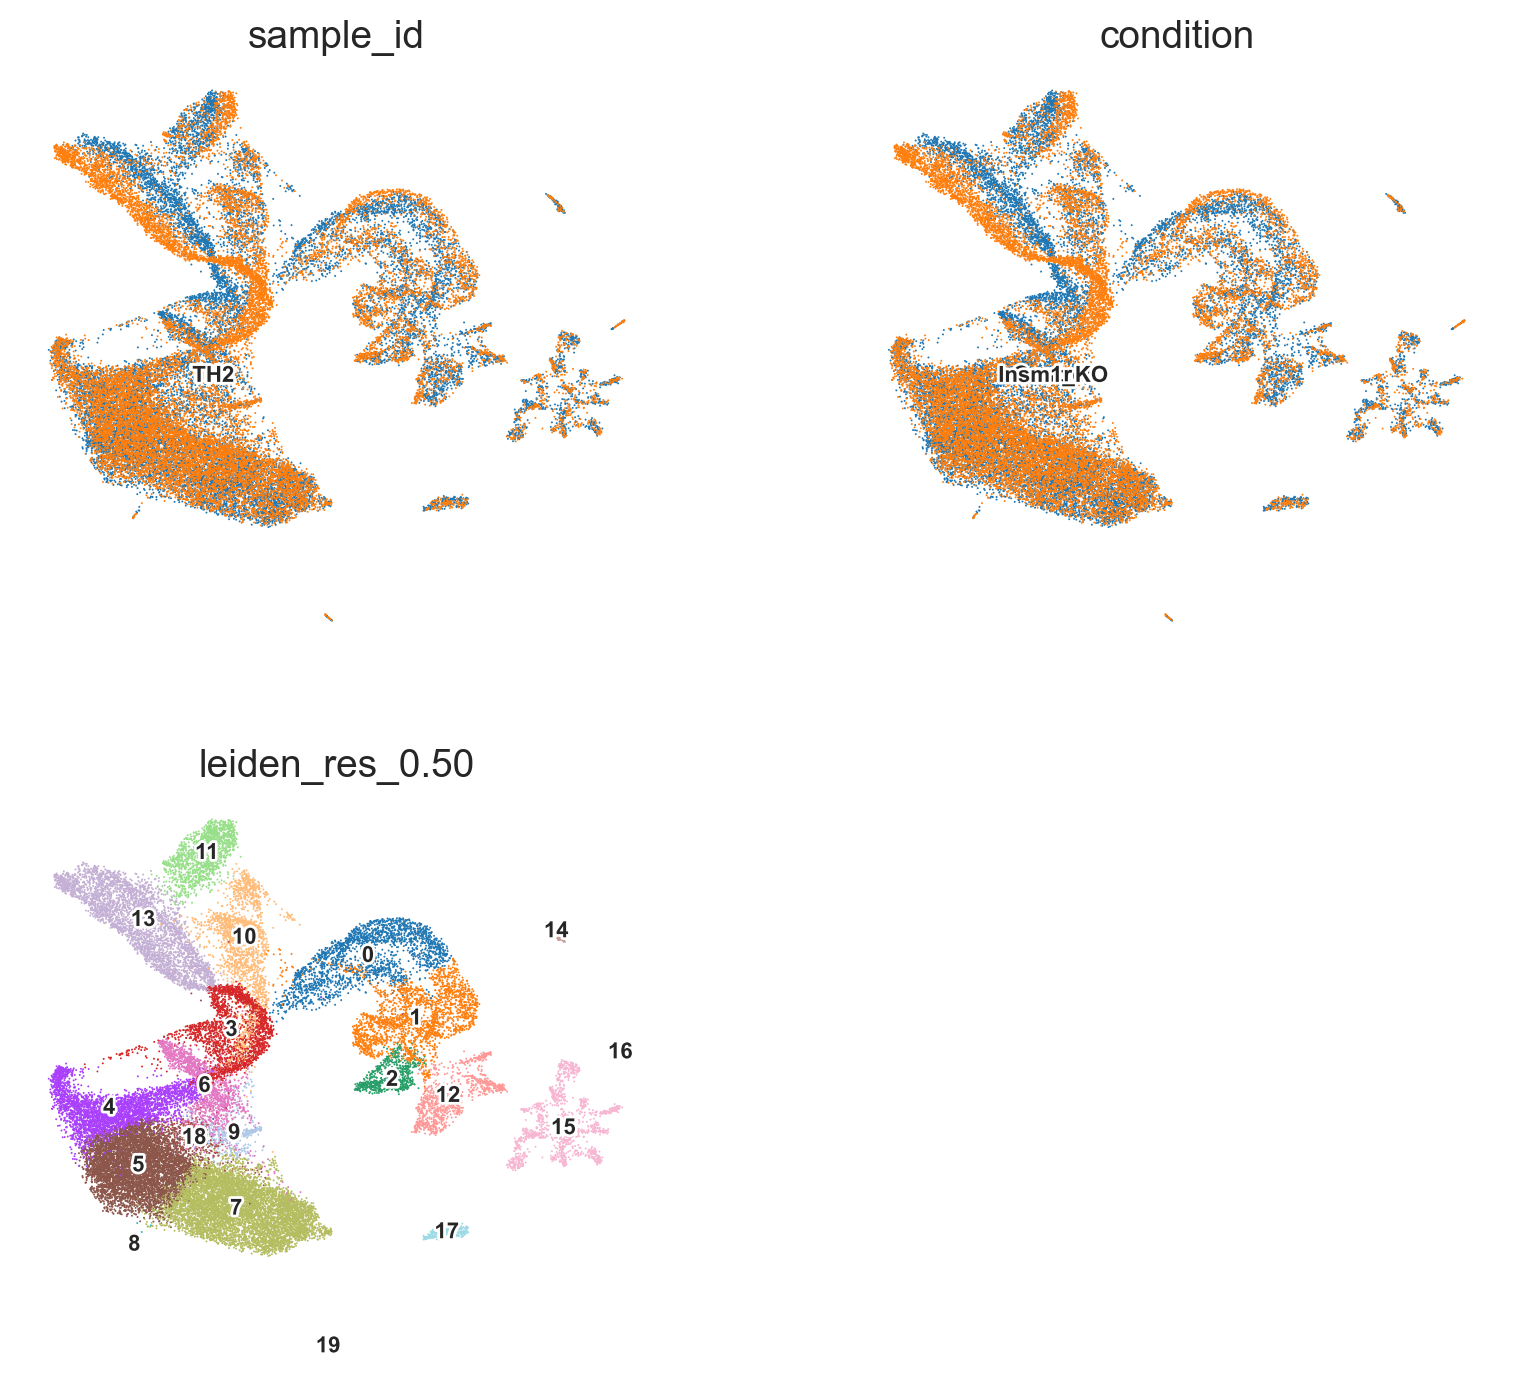

In [13]:
sc.pl.umap(
    adata,
    color=["sample_id", "condition", CLUSTER_KEY],
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    ncols=2,
    size=2,
)

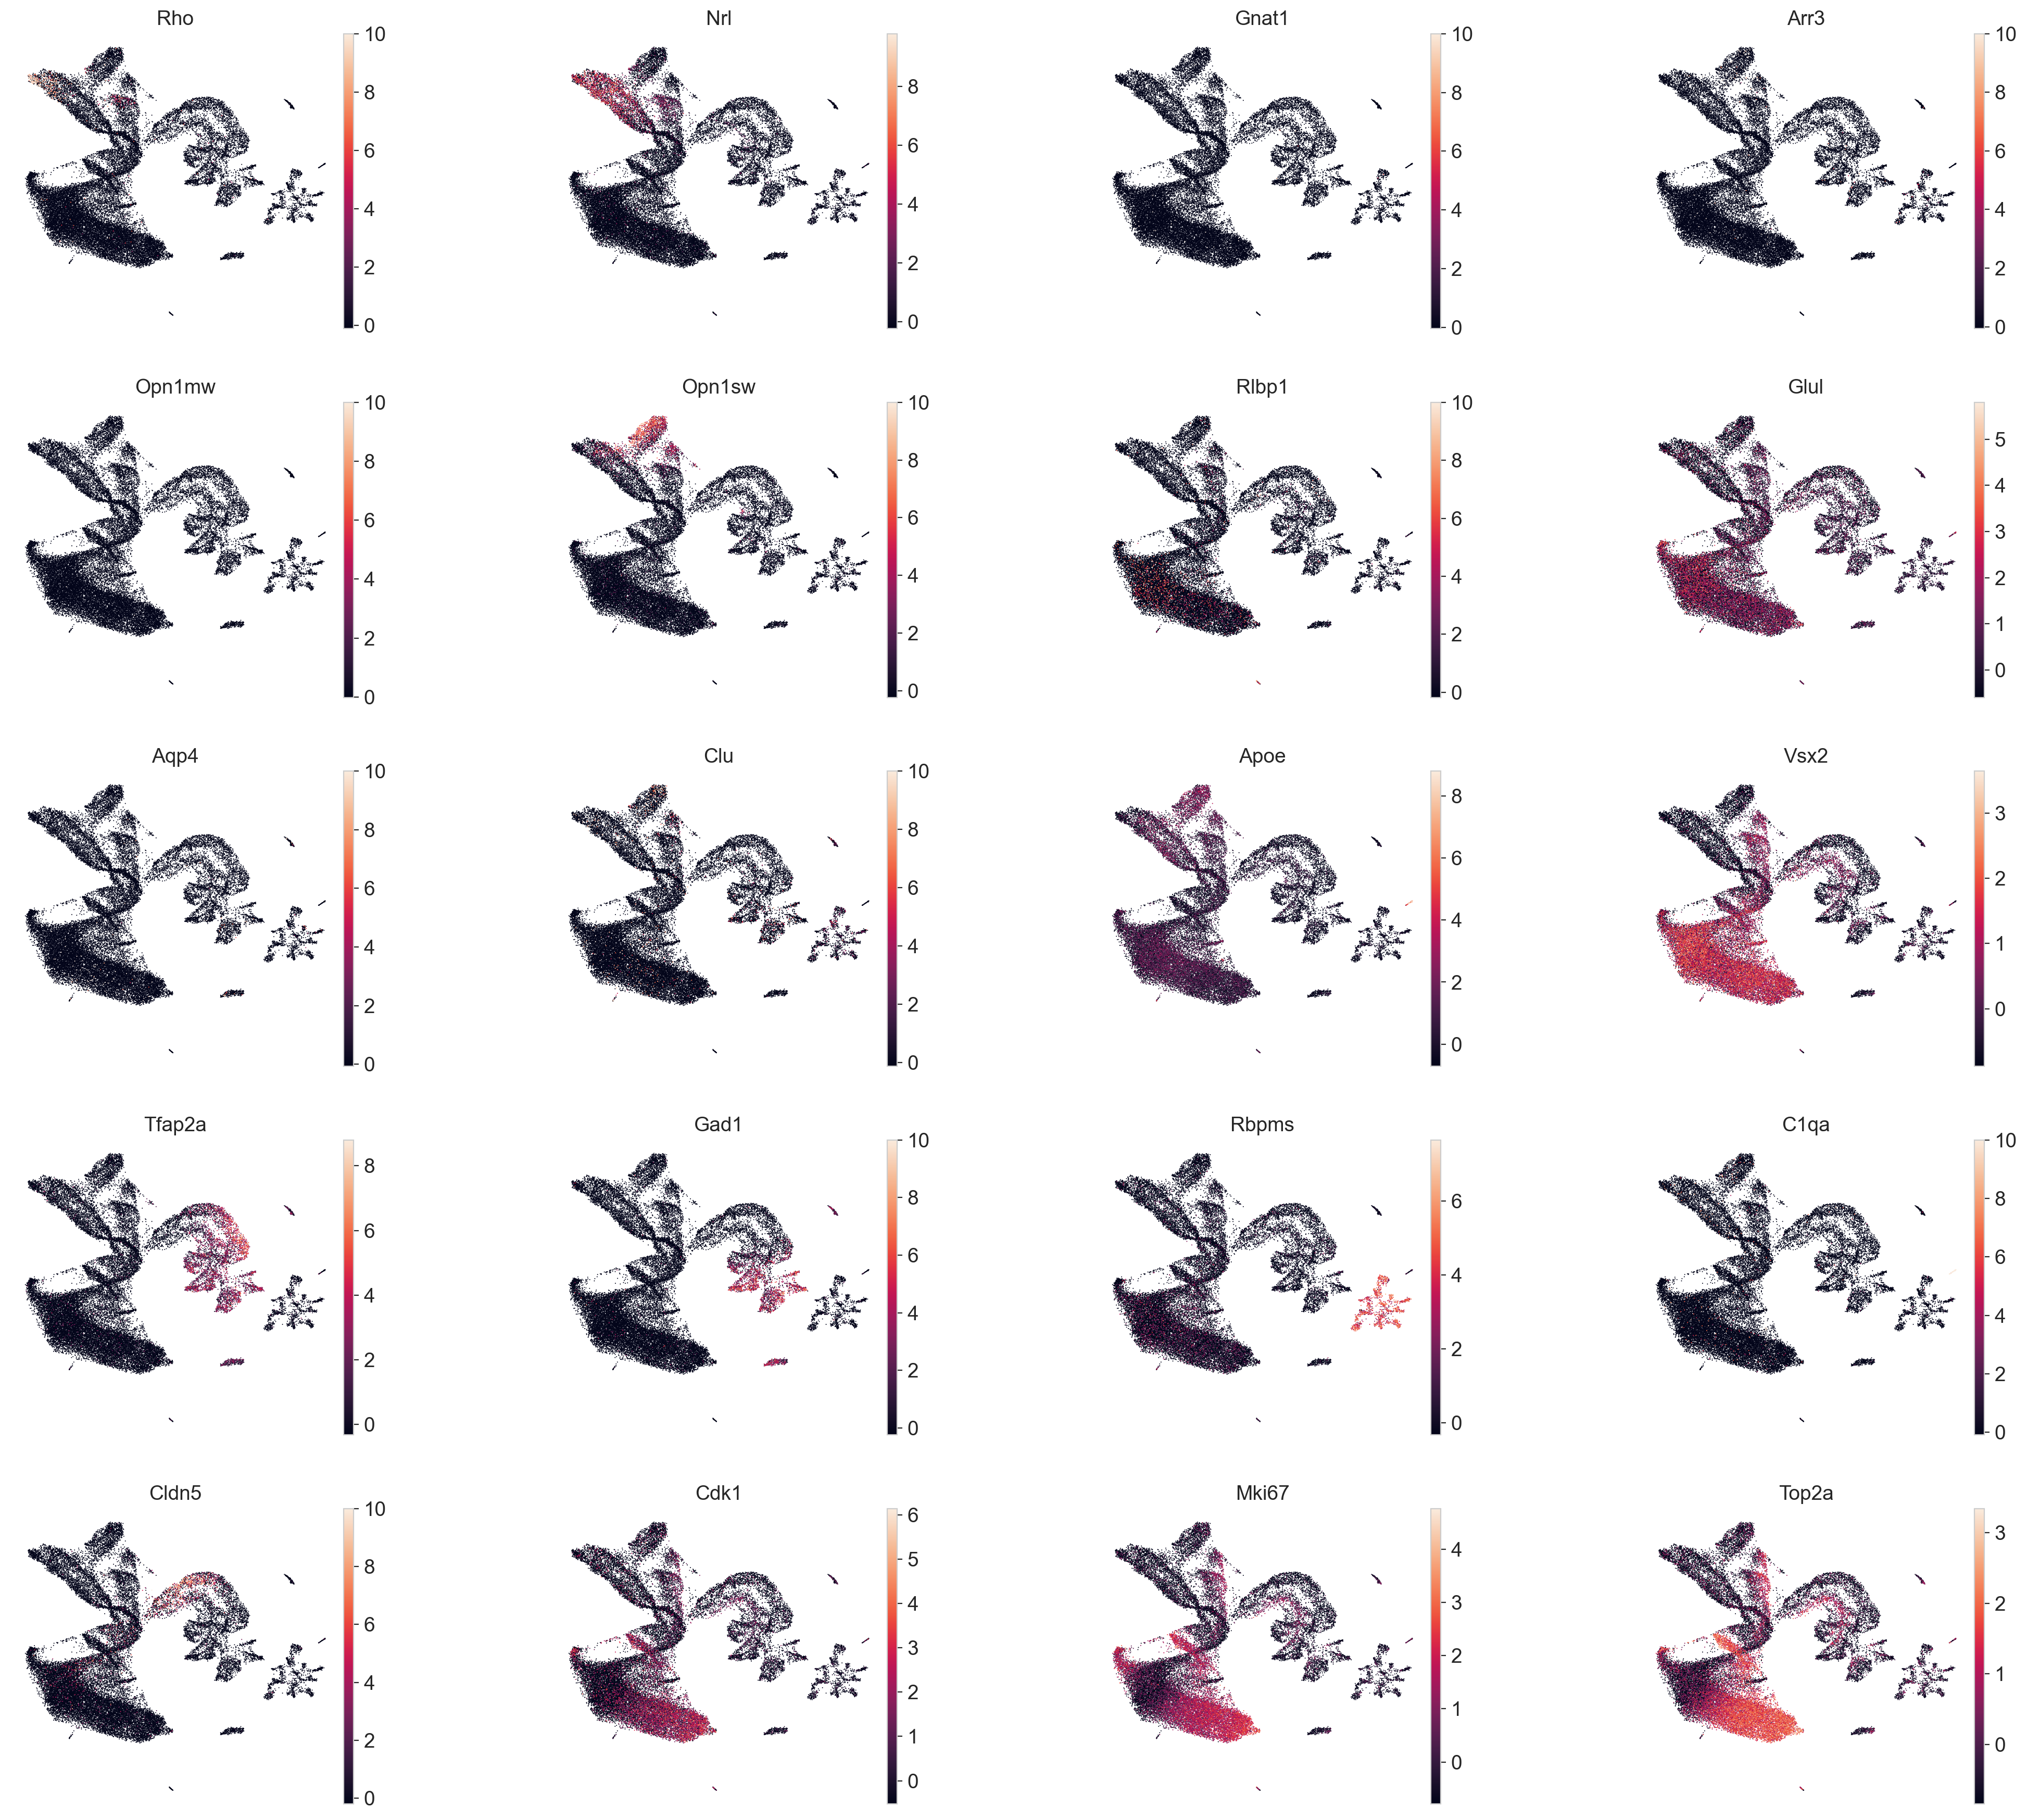

In [ ]:
key_markers = [
    "Rho", "Nrl", "Gnat1", "Arr3", "Opn1mw", "Opn1sw",
    "Rlbp1", "Glul", "Aqp4", "Clu", "Apoe", "Vsx2",
    "Tfap2a", "Gad1", "Rbpms", "C1qa", "Cldn5","Cdk1", "Mki67", "Top2a",
    "Ascl1", "Neurog2", "Neurod1", "Atoh7", "Sox2", "Hes1", "Hes5", "Insm1", "Prdm1", "Otx2", "Crx", "Olig2", "Foxn4"
]
key_markers = [gene for gene in key_markers if gene in adata.var_names]
sc.pl.umap(adata, color=key_markers, ncols=4, wspace=0.5, size=2)

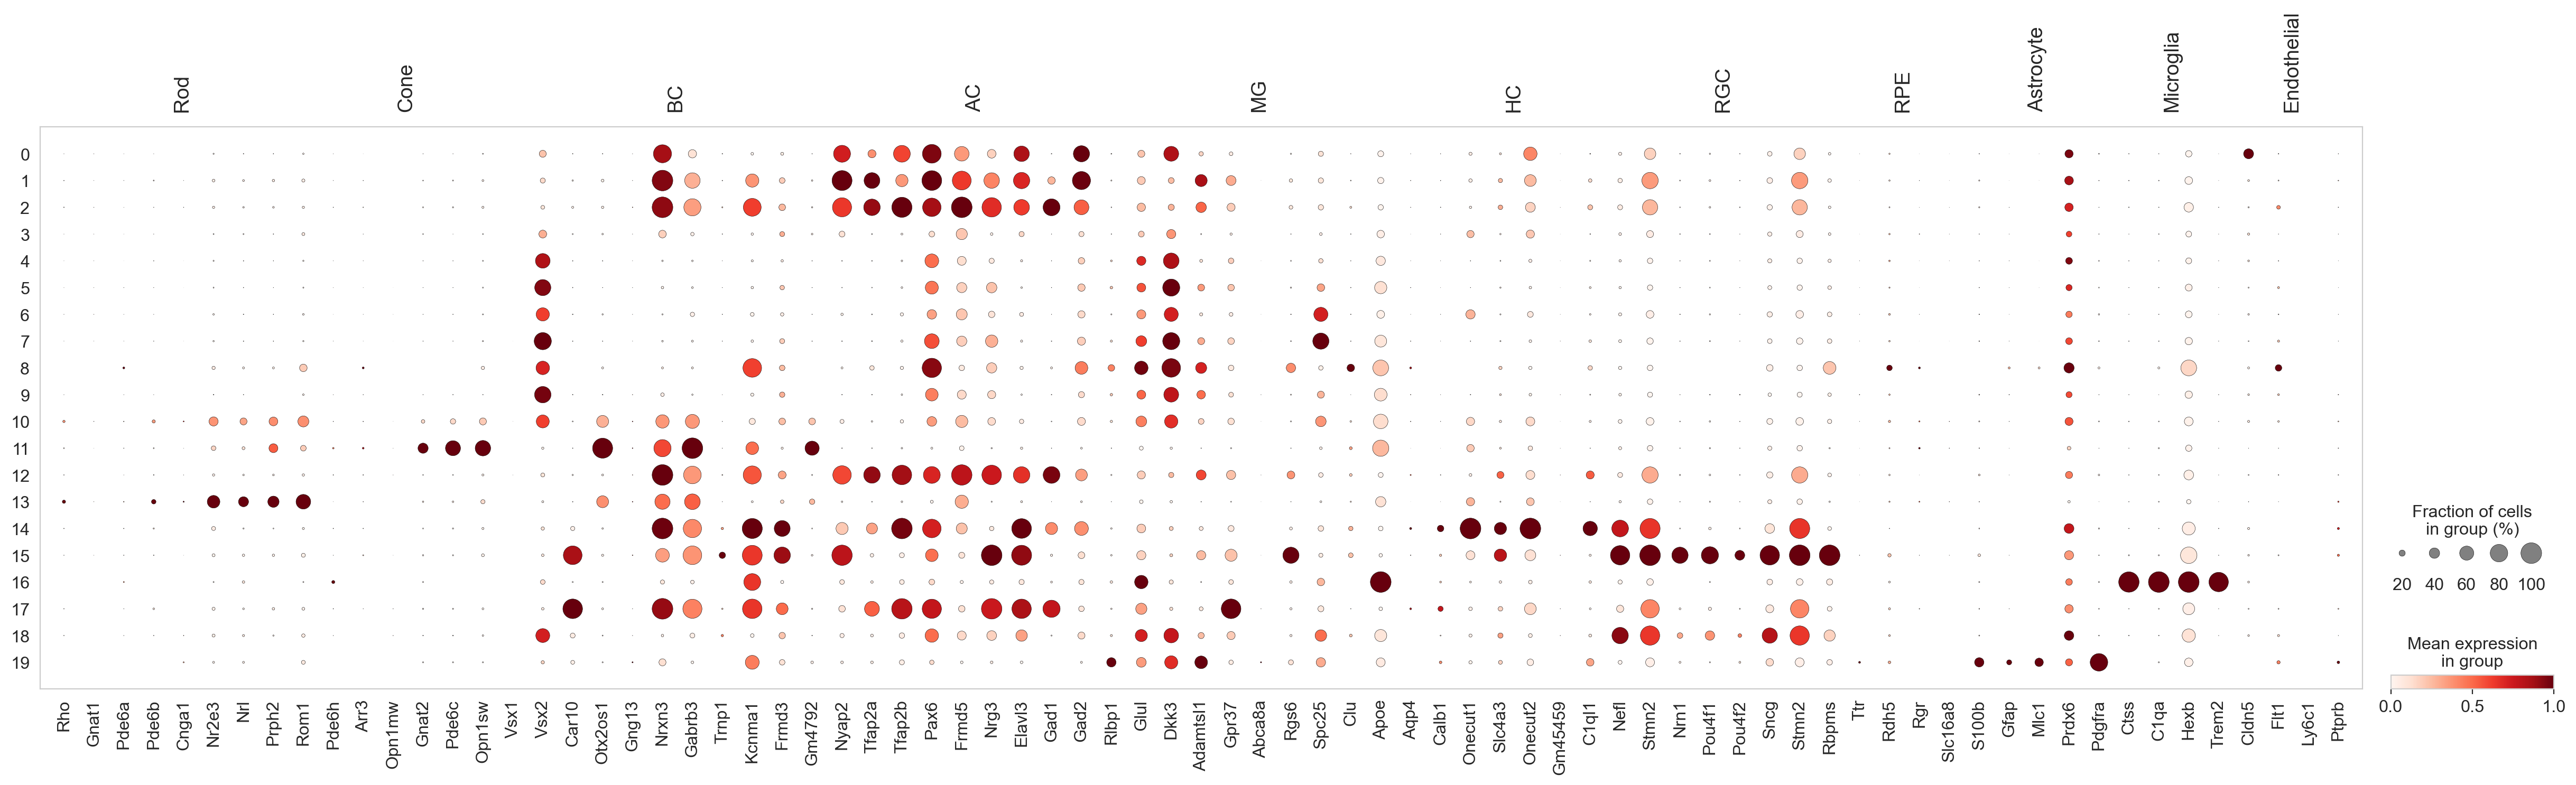

In [15]:
sc.pl.dotplot(adata, available_marker_genes, groupby=CLUSTER_KEY, standard_scale="var")

## Marker scores and suggested labels

In [16]:
score_columns = []
for cell_type, genes in available_marker_genes.items():
    if len(genes) < 2:
        continue
    score_col = f"score_{cell_type}"
    sc.tl.score_genes(adata, gene_list=genes, score_name=score_col)
    score_columns.append(score_col)

cluster_counts = adata.obs[CLUSTER_KEY].value_counts().sort_index()
cluster_marker_scores = adata.obs.groupby(CLUSTER_KEY, observed=True)[score_columns].mean()
cluster_marker_scores["suggested_celltype"] = cluster_marker_scores[score_columns].idxmax(axis=1).str.replace("score_", "", regex=False)
cluster_marker_scores["n_cells"] = cluster_counts.reindex(cluster_marker_scores.index).astype(int)
cluster_marker_scores = cluster_marker_scores[["n_cells", "suggested_celltype", *score_columns]]
cluster_marker_scores.to_csv(ANNOTATION_DIR / "03_cluster_marker_scores.csv")
cluster_marker_scores

KeyboardInterrupt: 

In [ ]:
# sc.tl.rank_genes_groups(adata, groupby=CLUSTER_KEY, method="wilcoxon", pts=True)
# top_cluster_markers = sc.get.rank_genes_groups_df(adata, group=None)
# top_cluster_markers.to_csv(ANNOTATION_DIR / "03_rank_genes_by_cluster.csv", index=False)

# cluster_top_genes = (
#     top_cluster_markers
#     .dropna(subset=["names"])
#     .sort_values(["group", "pvals_adj", "scores"])
#     .groupby("group", observed=True)
#     .head(8)
#     .groupby("group", observed=True)["names"]
#     .apply(lambda genes: ", ".join(genes.astype(str)))
#     .to_frame("top_marker_genes")
# )
# cluster_review = cluster_marker_scores.join(cluster_top_genes, how="left")
# cluster_review.to_csv(ANNOTATION_DIR / "03_cluster_review_table.csv")
# cluster_review

## Manual annotation

Edit `manual_annotation` after reviewing the UMAPs, dotplot, marker scores, and top marker genes.

In [ ]:
manual_annotation = cluster_marker_scores["suggested_celltype"].to_dict()
manual_annotation

{'0': 'AC',
 '1': 'AC',
 '2': 'AC',
 '3': 'HC',
 '4': 'Astrocyte',
 '5': 'MG',
 '6': 'HC',
 '7': 'MG',
 '8': 'MG',
 '9': 'MG',
 '10': 'Rod',
 '11': 'Cone',
 '12': 'AC',
 '13': 'Rod',
 '14': 'HC',
 '15': 'RGC',
 '16': 'Microglia',
 '17': 'AC',
 '18': 'RGC',
 '19': 'Astrocyte'}

In [ ]:
adata.obs["manual_celltype_annotation"] = adata.obs[CLUSTER_KEY].map(manual_annotation).astype("category")

annotation_table = pd.DataFrame({
    CLUSTER_KEY: list(manual_annotation.keys()),
    "manual_celltype_annotation": list(manual_annotation.values()),
})
annotation_table["n_cells"] = annotation_table[CLUSTER_KEY].map(cluster_counts).astype(int)
annotation_table.to_csv(ANNOTATION_DIR / "03_cluster_annotations.csv", index=False)
annotation_table

,leiden_res_0.50,manual_celltype_annotation,n_cells
0,0,AC,2060
1,1,AC,2150
2,2,AC,650
3,3,HC,2208
4,4,Astrocyte,3591
5,5,MG,5865
6,6,HC,1502
7,7,MG,6927
8,8,MG,23
9,9,MG,405


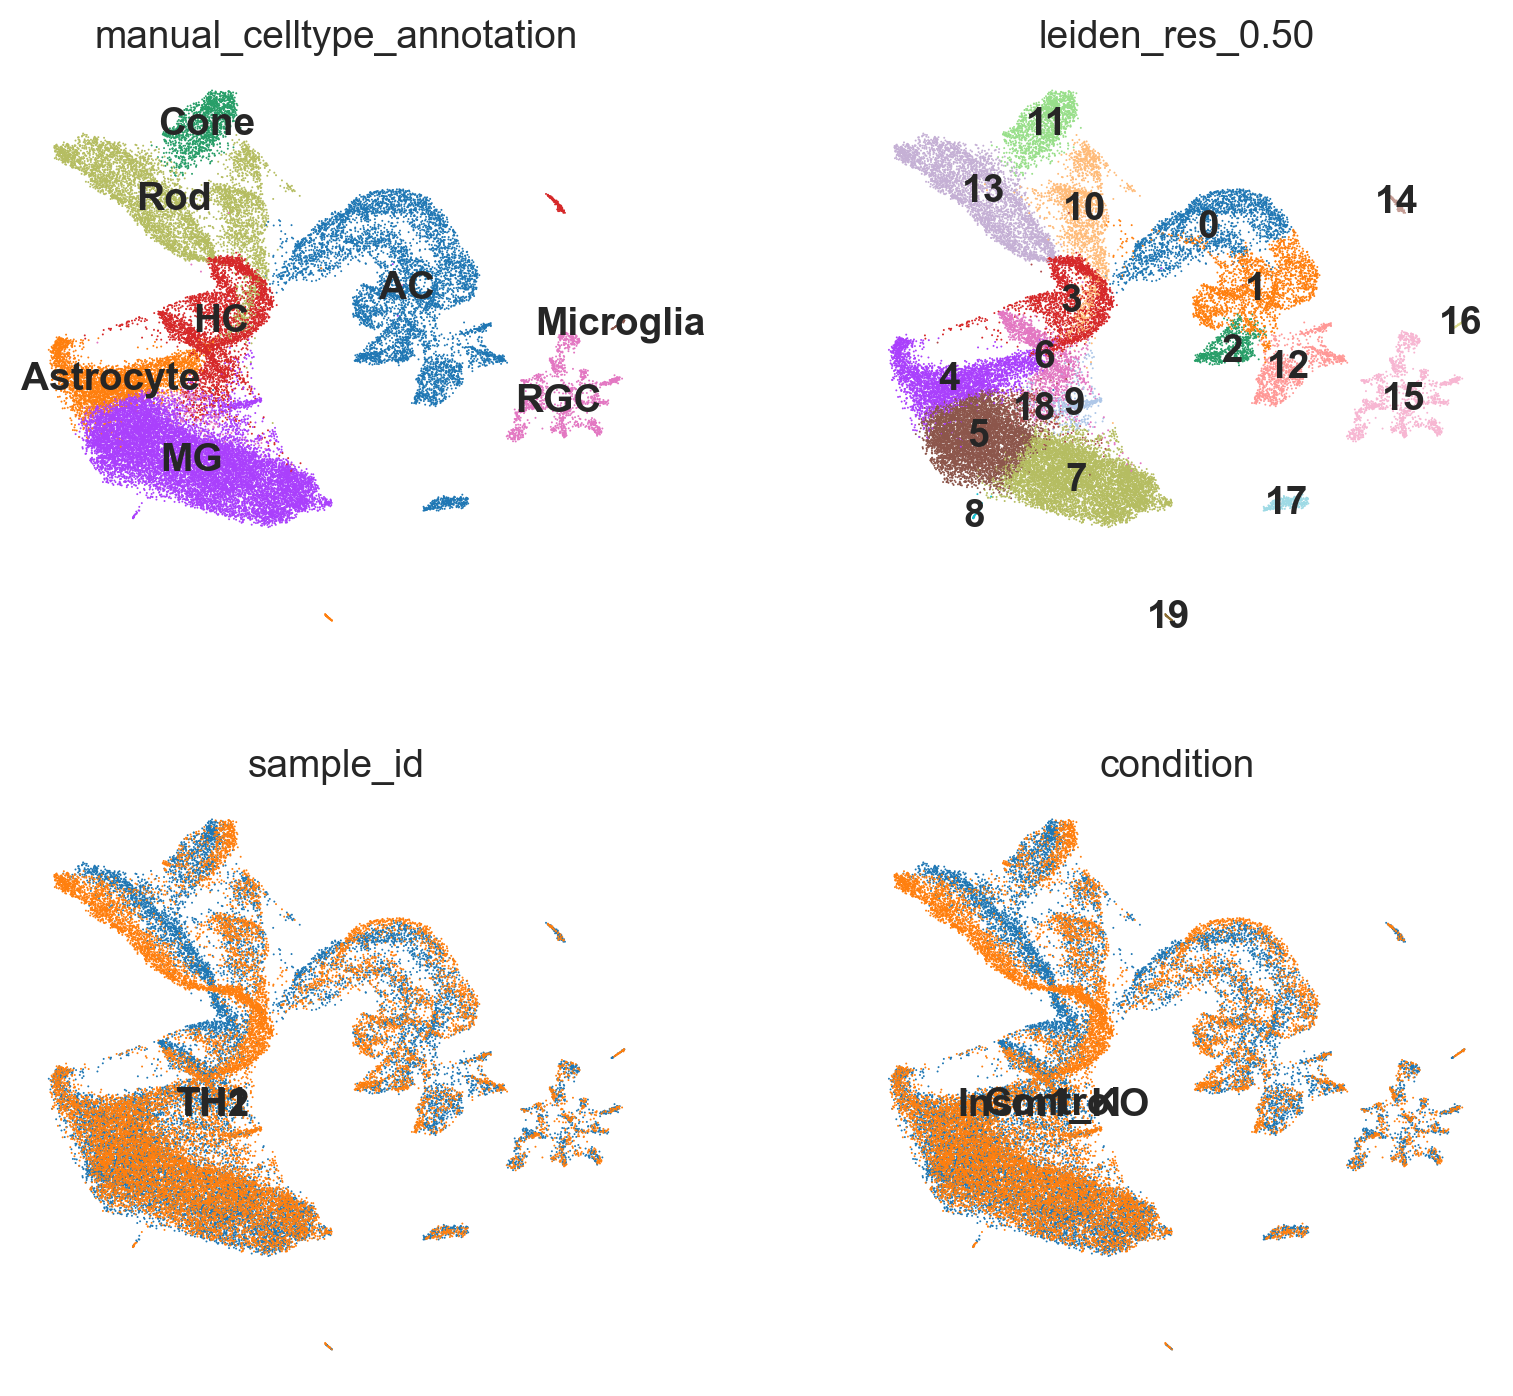

In [ ]:
sc.pl.umap(
    adata,
    color=["manual_celltype_annotation", CLUSTER_KEY, "sample_id", "condition"],
    legend_loc="on data",
    ncols=2,
    size=2,
)

In [ ]:
celltype_counts = pd.crosstab(adata.obs["manual_celltype_annotation"], adata.obs["condition"])
celltype_counts.to_csv(ANNOTATION_DIR / "03_celltype_counts_by_condition.csv")
celltype_counts

condition,Control,Insm1_KO
manual_celltype_annotation,,
AC,3415,2749
Astrocyte,1768,1869
Cone,810,600
HC,1738,2097
MG,6321,6899
Microglia,24,26
RGC,903,631
Rod,2365,2997


In [ ]:
adata.write(OUTPUT_H5AD)
print(f"Saved annotated AnnData: {OUTPUT_H5AD}")